# Charger/Adapter Source 1 — Computer Charger Roboflow Dataset

Purpose: inspect the first public dataset source for the E-Safe Dataset A class `charger_adapter`.

The raw downloaded dataset will remain unchanged.

This EDA will examine:
- dataset structure and source labels
- image and annotation counts
- charger/adapter representation
- image dimensions and corrupt files
- object prominence
- background and source bias
- duplicates and near-duplicates
- suitability for mapping to `charger_adapter`

In [1]:
from pathlib import Path

dataset_path = Path(
    "../../data/item_images/raw/charger_source1_roboflow"
)

print("Exists:", dataset_path.exists())

for path in dataset_path.rglob("*"):
    if path.is_dir():
        print(path)

Exists: True
..\..\data\item_images\raw\charger_source1_roboflow\test
..\..\data\item_images\raw\charger_source1_roboflow\train
..\..\data\item_images\raw\charger_source1_roboflow\valid
..\..\data\item_images\raw\charger_source1_roboflow\test\images
..\..\data\item_images\raw\charger_source1_roboflow\test\labels
..\..\data\item_images\raw\charger_source1_roboflow\train\images
..\..\data\item_images\raw\charger_source1_roboflow\train\labels
..\..\data\item_images\raw\charger_source1_roboflow\valid\images
..\..\data\item_images\raw\charger_source1_roboflow\valid\labels


In [2]:
from collections import Counter

extensions = Counter()

for file in dataset_path.rglob("*"):
    if file.is_file():
        extensions[file.suffix.lower()] += 1

print(extensions)

Counter({'.txt': 452, '.jpg': 450, '.yaml': 1})


In [3]:
yaml_files = list(dataset_path.rglob("*.yaml"))

print("YAML files:", yaml_files)

if yaml_files:
    with open(yaml_files[0], "r") as f:
        print(f.read())

YAML files: [WindowsPath('../../data/item_images/raw/charger_source1_roboflow/data.yaml')]
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['computer_charger']

roboflow:
  workspace: charger-fbhkw
  project: sacmaytinh
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/charger-fbhkw/sacmaytinh/dataset/1


In [4]:
for split in ["train", "valid", "test"]:

    image_dir = dataset_path / split / "images"
    label_dir = dataset_path / split / "labels"

    images = (
        [
            f for f in image_dir.iterdir()
            if f.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"}
        ]
        if image_dir.exists()
        else []
    )

    labels = (
        list(label_dir.glob("*.txt"))
        if label_dir.exists()
        else []
    )

    print(
        split,
        "| images:", len(images),
        "| labels:", len(labels)
    )

train | images: 315 | labels: 315
valid | images: 90 | labels: 90
test | images: 45 | labels: 45


In [5]:
from pathlib import Path

image_extensions = {".jpg", ".jpeg", ".png", ".webp"}

all_images = []
all_labels = []

for split in ["train", "valid", "test"]:

    image_dir = dataset_path / split / "images"
    label_dir = dataset_path / split / "labels"

    split_images = [
        f for f in image_dir.iterdir()
        if f.suffix.lower() in image_extensions
    ]

    split_labels = list(label_dir.glob("*.txt"))

    all_images.extend([(split, f) for f in split_images])
    all_labels.extend([(split, f) for f in split_labels])

    image_stems = {f.stem for f in split_images}
    label_stems = {f.stem for f in split_labels}

    print(f"\n{split.upper()}")
    print("Images:", len(split_images))
    print("Labels:", len(split_labels))
    print("Images without labels:", len(image_stems - label_stems))
    print("Labels without images:", len(label_stems - image_stems))


TRAIN
Images: 315
Labels: 315
Images without labels: 0
Labels without images: 0

VALID
Images: 90
Labels: 90
Images without labels: 0
Labels without images: 0

TEST
Images: 45
Labels: 45
Images without labels: 0
Labels without images: 0


In [6]:
def windows_long_path(path):
    path = Path(path).resolve()
    return "\\\\?\\" + str(path)

In [7]:
from collections import Counter

object_count_distribution = Counter()
total_objects = 0

for split, label_file in all_labels:

    with open(windows_long_path(label_file), "r") as f:
        lines = [
            line.strip()
            for line in f
            if line.strip()
        ]

    object_count_distribution[len(lines)] += 1
    total_objects += len(lines)

print("Total images:", len(all_images))
print("Total charger objects:", total_objects)

print("\nObjects per image:")
for count, num_images in sorted(object_count_distribution.items()):
    print(count, "object(s):", num_images, "images")

Total images: 450
Total charger objects: 457

Objects per image:
0 object(s): 1 images
1 object(s): 441 images
2 object(s): 8 images


In [8]:
class_ids = Counter()

for split, label_file in all_labels:

    with open(windows_long_path(label_file), "r") as f:
        for line in f:

            values = line.strip().split()

            if values:
                class_ids[int(values[0])] += 1

print(class_ids)

Counter({0: 457})


In [9]:
from PIL import Image
from collections import Counter

size_counts = Counter()
corrupt_images = []

for split, image_path in all_images:

    try:
        with Image.open(windows_long_path(image_path)) as img:
            size_counts[img.size] += 1
            img.verify()

    except Exception as e:
        corrupt_images.append((image_path.name, str(e)))

print("Image dimensions:")
print(size_counts)

print("\nCorrupt images:", len(corrupt_images))

Image dimensions:
Counter({(640, 640): 450})

Corrupt images: 0



SPLIT: train


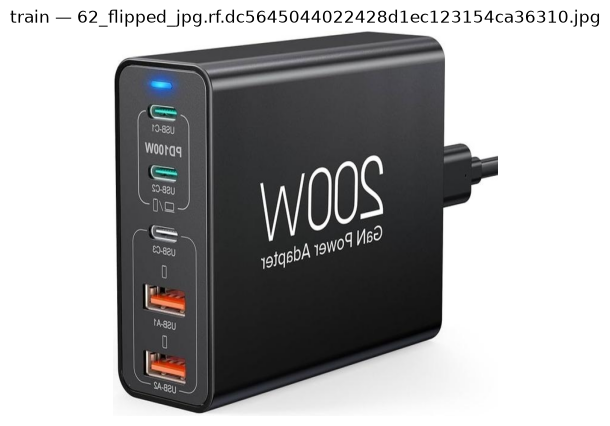

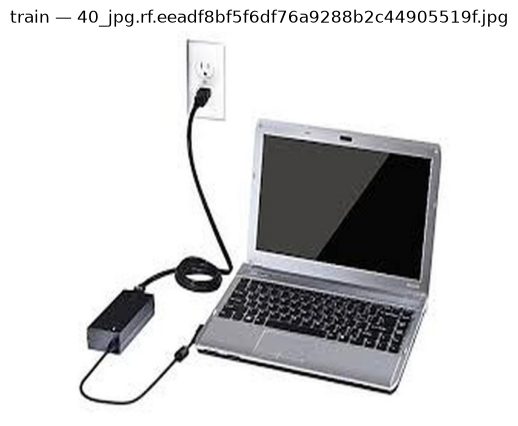

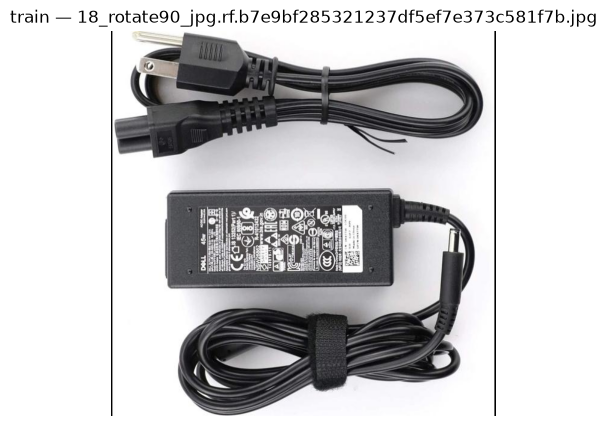

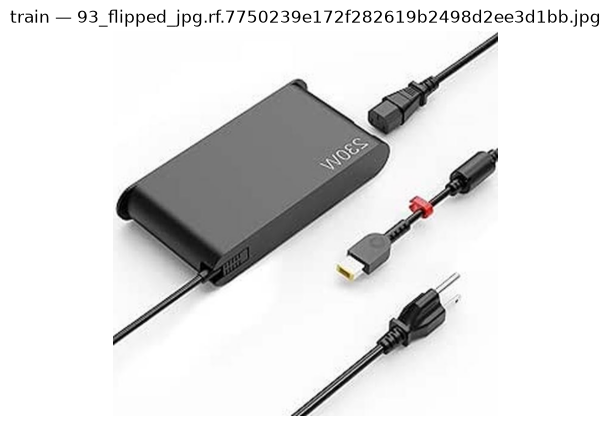

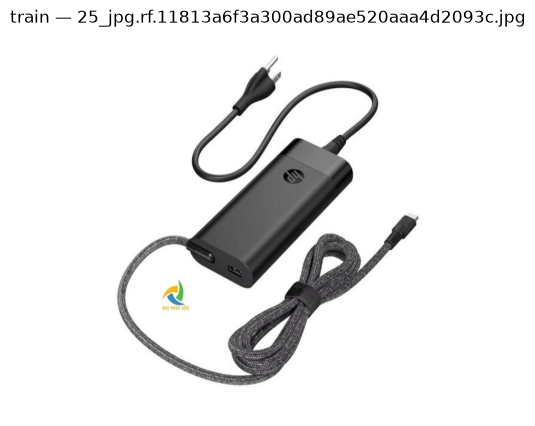


SPLIT: valid


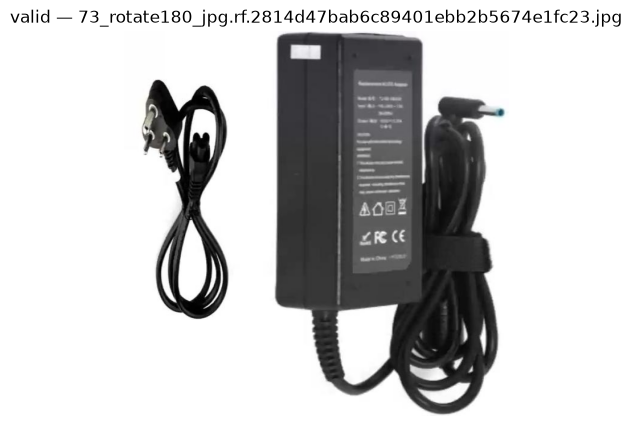

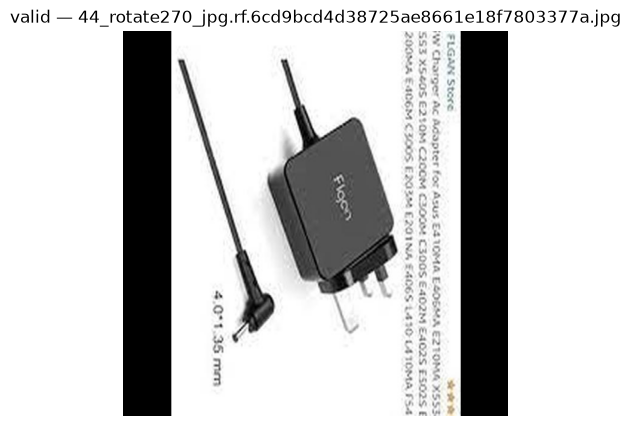

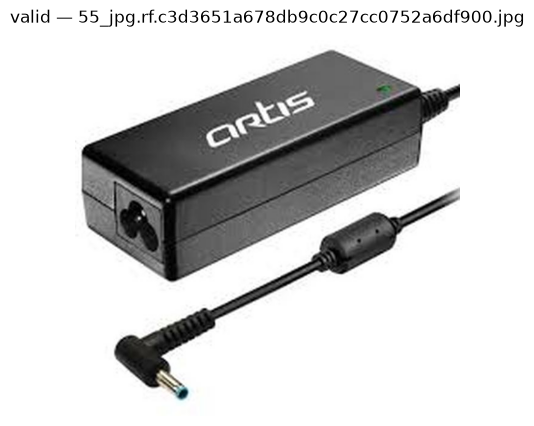

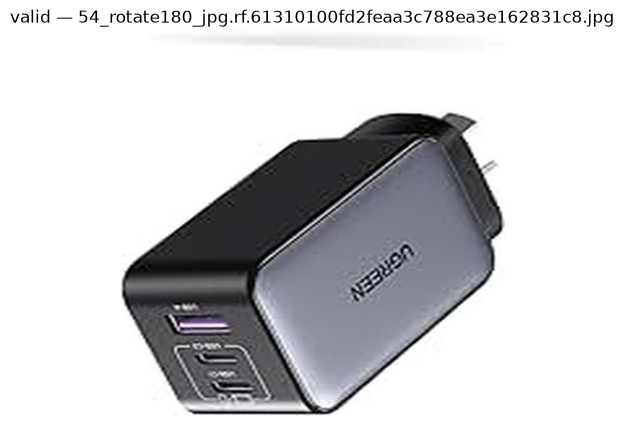

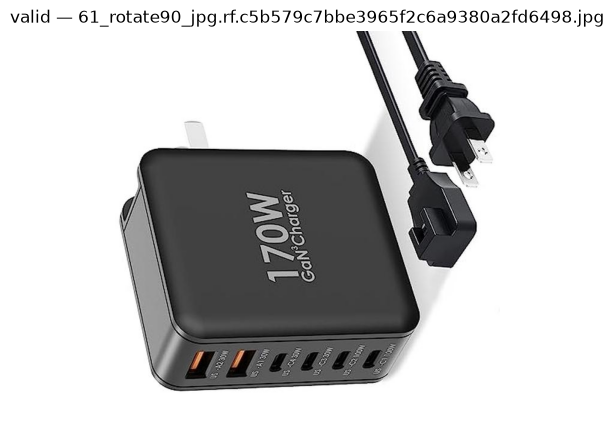


SPLIT: test


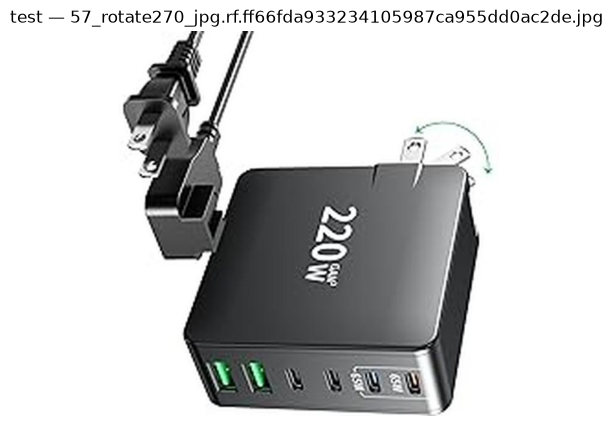

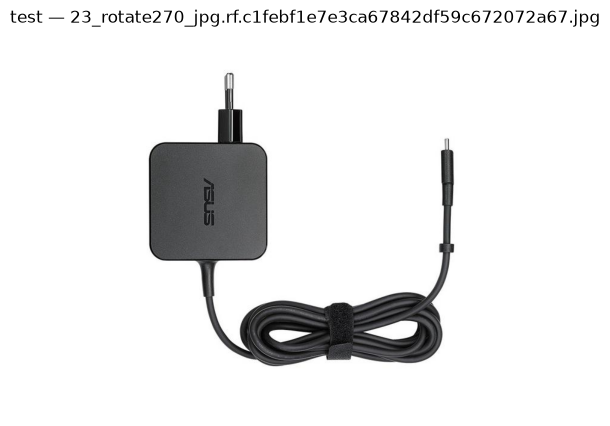

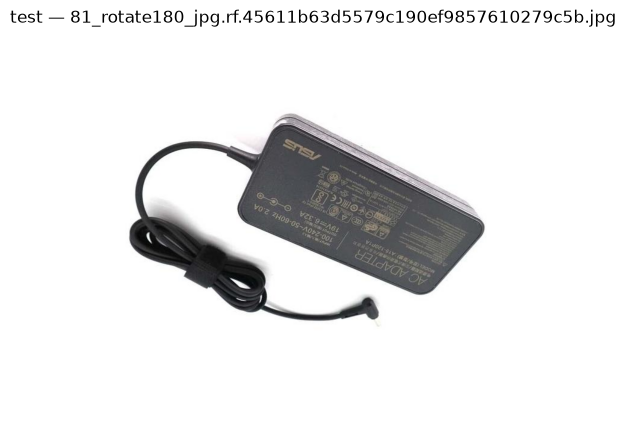

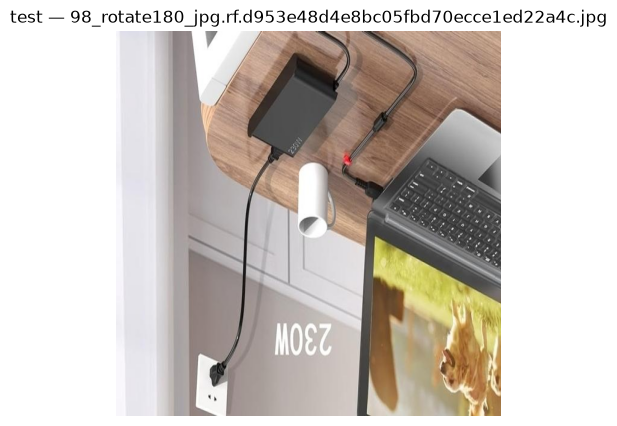

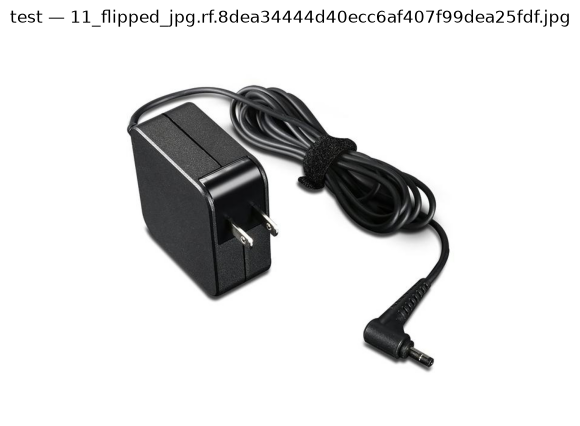

In [10]:
import random
import matplotlib.pyplot as plt
from PIL import Image

for split in ["train", "valid", "test"]:

    split_images = [
        image_path
        for image_split, image_path in all_images
        if image_split == split
    ]

    samples = random.sample(
        split_images,
        min(5, len(split_images))
    )

    print(f"\nSPLIT: {split}")

    for image_path in samples:

        img = Image.open(
            windows_long_path(image_path)
        )

        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        plt.title(f"{split} — {image_path.name}")
        plt.axis("off")
        plt.show()

In [11]:
import pandas as pd

charger_rows = []

for split, label_file in all_labels:

    with open(windows_long_path(label_file), "r") as f:
        lines = [
            line.strip()
            for line in f
            if line.strip()
        ]

    bbox_ratios = []

    for line in lines:
        values = line.split()

        width = float(values[3])
        height = float(values[4])

        bbox_ratios.append(width * height)

    charger_rows.append({
        "file_name": label_file.stem + ".jpg",
        "original_split": split,
        "object_count": len(lines),
        "largest_bbox_ratio": (
            max(bbox_ratios)
            if bbox_ratios
            else None
        )
    })

charger_df = pd.DataFrame(charger_rows)

print(charger_df.shape)

print("\nBounding-box statistics:")
print(
    charger_df["largest_bbox_ratio"]
    .dropna()
    .describe()
)

print("\nImages with zero annotations:")
print(
    charger_df[
        charger_df["object_count"] == 0
    ][["file_name", "original_split"]]
)

(450, 4)

Bounding-box statistics:
count    449.000000
mean       0.364123
std        0.185269
min        0.026212
25%        0.229230
50%        0.329688
75%        0.487122
max        0.925430
Name: largest_bbox_ratio, dtype: float64

Images with zero annotations:
                                          file_name original_split
270  89_jpg.rf.973198fe202af4ae5c941d4581d1c784.jpg          train


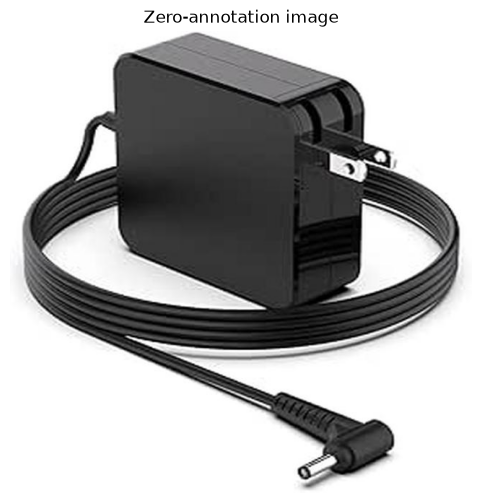

In [12]:
zero_row = charger_df[charger_df["object_count"] == 0].iloc[0]

zero_image_path = (
    dataset_path
    / zero_row["original_split"]
    / "images"
    / zero_row["file_name"]
)

img = Image.open(windows_long_path(zero_image_path))

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Zero-annotation image")
plt.axis("off")
plt.show()

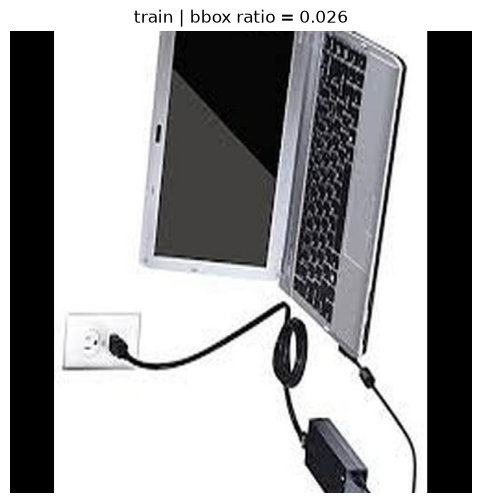

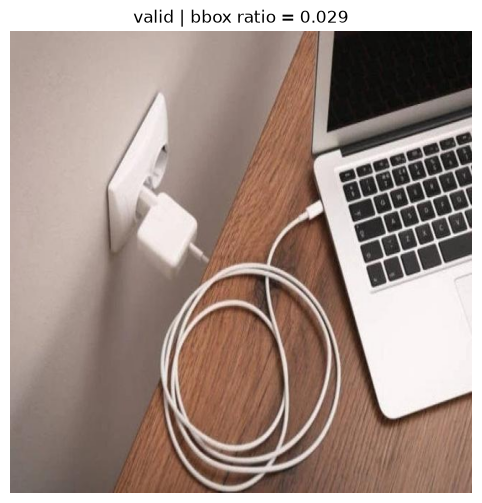

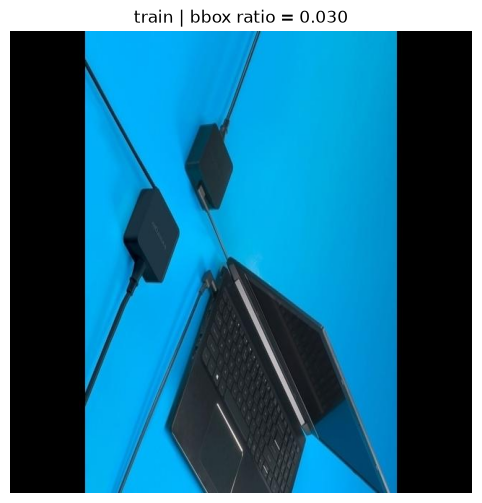

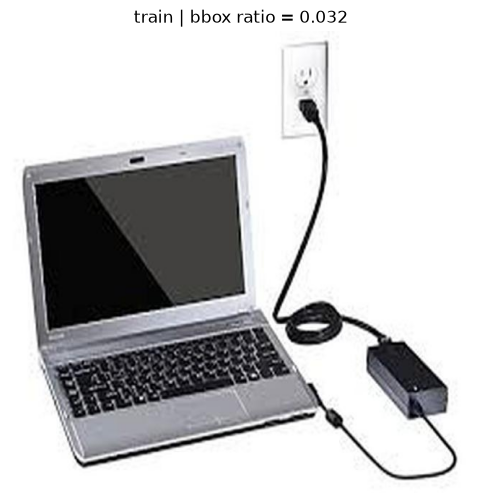

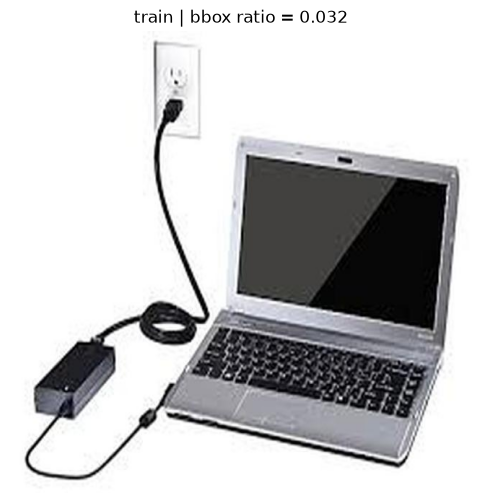

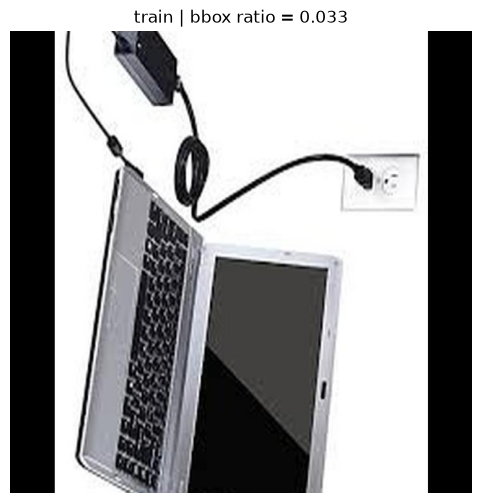

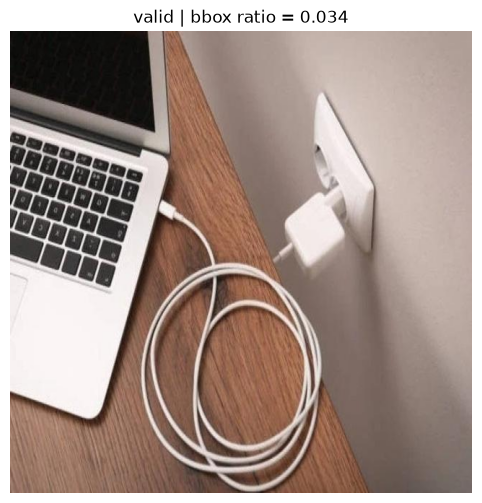

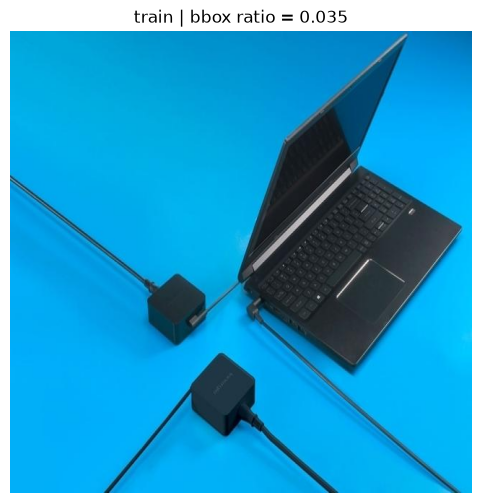

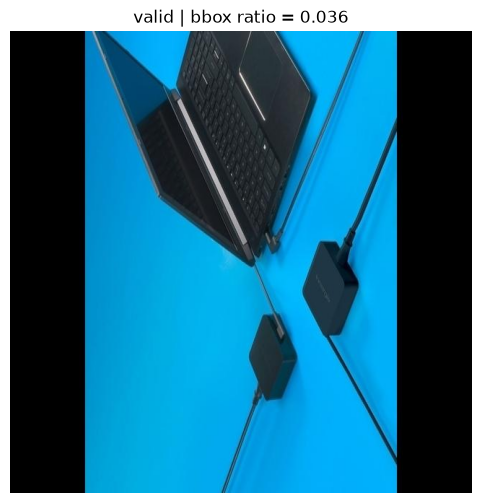

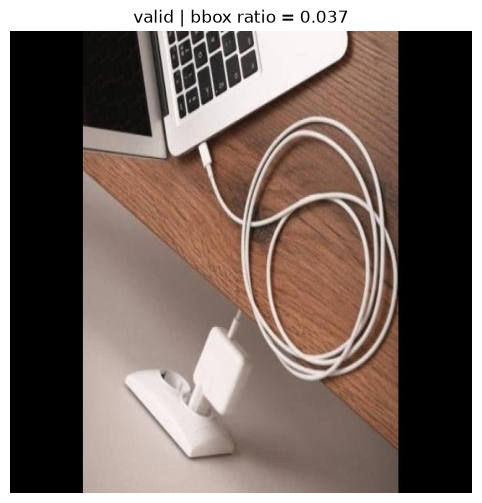

In [13]:
smallest = (
    charger_df
    .dropna(subset=["largest_bbox_ratio"])
    .sort_values("largest_bbox_ratio")
    .head(10)
)

for _, row in smallest.iterrows():

    image_path = (
        dataset_path
        / row["original_split"]
        / "images"
        / row["file_name"]
    )

    img = Image.open(windows_long_path(image_path))

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.title(
        f"{row['original_split']} | "
        f"bbox ratio = {row['largest_bbox_ratio']:.3f}"
    )
    plt.axis("off")
    plt.show()

In [14]:
keywords = [
    "flipped",
    "flip",
    "rotated",
    "rotate",
    "aug",
    "bright",
    "blur"
]

for keyword in keywords:

    matches = [
        image_path.name
        for split, image_path in all_images
        if keyword.lower() in image_path.name.lower()
    ]

    print(keyword, ":", len(matches))

    for name in matches[:5]:
        print("   ", name)

flipped : 91
    100_flipped_jpg.rf.3d296e8ae7e0dae14f55b889c053faac.jpg
    10_flipped_jpg.rf.f4264c5a24aa2570c0cb06cfb5061af4.jpg
    12_flipped_jpg.rf.6c2b71b6349d4b47d2cb1d6463d4a77c.jpg
    13_flipped_jpg.rf.1688cd4710458df946f137388f0526f7.jpg
    14_flipped_jpg.rf.d41055c0cdfc75330ab38d8391fc78e9.jpg
flip : 91
    100_flipped_jpg.rf.3d296e8ae7e0dae14f55b889c053faac.jpg
    10_flipped_jpg.rf.f4264c5a24aa2570c0cb06cfb5061af4.jpg
    12_flipped_jpg.rf.6c2b71b6349d4b47d2cb1d6463d4a77c.jpg
    13_flipped_jpg.rf.1688cd4710458df946f137388f0526f7.jpg
    14_flipped_jpg.rf.d41055c0cdfc75330ab38d8391fc78e9.jpg
rotated : 0
rotate : 270
    100_rotate270_jpg.rf.9158bd38076810944b661ecbc802cb7a.jpg
    100_rotate90_jpg.rf.1ccdb5bd4ac3facc983bc90ac194b5f5.jpg
    10_rotate180_jpg.rf.71efee5518456d616ea07f6c4105795d.jpg
    10_rotate270_jpg.rf.740a87fbdaec09f58e64fa788dc044c7.jpg
    10_rotate90_jpg.rf.672d89691161d0720a2f2a20dd5baa86.jpg
aug : 0
bright : 0
blur : 0


In [15]:
import hashlib

hash_groups = {}

for split, image_path in all_images:

    with open(windows_long_path(image_path), "rb") as f:
        file_hash = hashlib.md5(f.read()).hexdigest()

    hash_groups.setdefault(file_hash, []).append(
        (split, image_path.name)
    )

exact_duplicates = [
    group
    for group in hash_groups.values()
    if len(group) > 1
]

print("Exact duplicate groups:", len(exact_duplicates))

for group in exact_duplicates:
    print(group)

Exact duplicate groups: 0


In [16]:
import re
import pandas as pd

family_rows = []

for split, image_path in all_images:

    name = image_path.name

    # Remove Roboflow hash section
    base = name.split(".rf.")[0]

    # Remove extension marker embedded in Roboflow filename
    base = re.sub(
        r"_(jpg|jpeg|png|webp)$",
        "",
        base,
        flags=re.IGNORECASE
    )

    # Identify augmentation
    augmentation = "original"

    if re.search(r"_flipped$", base, flags=re.IGNORECASE):
        augmentation = "flipped"
        base = re.sub(
            r"_flipped$",
            "",
            base,
            flags=re.IGNORECASE
        )

    elif re.search(r"_rotate90$", base, flags=re.IGNORECASE):
        augmentation = "rotate90"
        base = re.sub(r"_rotate90$", "", base, flags=re.IGNORECASE)

    elif re.search(r"_rotate180$", base, flags=re.IGNORECASE):
        augmentation = "rotate180"
        base = re.sub(r"_rotate180$", "", base, flags=re.IGNORECASE)

    elif re.search(r"_rotate270$", base, flags=re.IGNORECASE):
        augmentation = "rotate270"
        base = re.sub(r"_rotate270$", "", base, flags=re.IGNORECASE)

    family_rows.append({
        "file_name": name,
        "original_split": split,
        "augmentation_type": augmentation,
        "source_family": base
    })

family_df = pd.DataFrame(family_rows)

print("Total files:", len(family_df))
print("Unique source families:", family_df["source_family"].nunique())

print("\nAugmentation types:")
print(family_df["augmentation_type"].value_counts())

print("\nFamily size distribution:")
print(
    family_df.groupby("source_family")
    .size()
    .value_counts()
    .sort_index()
)

Total files: 450
Unique source families: 98

Augmentation types:
augmentation_type
flipped      91
rotate270    91
rotate180    90
rotate90     89
original     89
Name: count, dtype: int64

Family size distribution:
3     7
4    26
5    65
Name: count, dtype: int64


In [17]:
family_split_counts = (
    family_df
    .groupby("source_family")["original_split"]
    .nunique()
)

cross_split_families = family_split_counts[
    family_split_counts > 1
]

print(
    "Families appearing in multiple source splits:",
    len(cross_split_families)
)

for family in cross_split_families.index[:20]:

    print("\nFAMILY:", family)

    print(
        family_df[
            family_df["source_family"] == family
        ][
            [
                "file_name",
                "original_split",
                "augmentation_type"
            ]
        ].to_string(index=False)
    )

Families appearing in multiple source splits: 77

FAMILY: 1
                                              file_name original_split augmentation_type
  1_flipped_jpg.rf.05c729e4f55fde11d05bceda6442650b.jpg          train           flipped
          1_jpg.rf.f9c43b8cef455de2c66a6d5a44a39a4d.jpg          train          original
1_rotate180_jpg.rf.009aeb73b0ce4713ebb57c31a8f386e0.jpg          train         rotate180
 1_rotate90_jpg.rf.ffe510e5c091d0b0ab019e81fc40b78b.jpg          train          rotate90
1_rotate270_jpg.rf.d235977dfe7767bff81cb3fd60b81c16.jpg          valid         rotate270

FAMILY: 100
                                                file_name original_split augmentation_type
  100_flipped_jpg.rf.3d296e8ae7e0dae14f55b889c053faac.jpg          train           flipped
100_rotate270_jpg.rf.9158bd38076810944b661ecbc802cb7a.jpg          train         rotate270
 100_rotate90_jpg.rf.1ccdb5bd4ac3facc983bc90ac194b5f5.jpg          train          rotate90
          100_jpg.rf.0e727194

In [18]:
representatives = []

for family, group in family_df.groupby("source_family"):

    originals = group[
        group["augmentation_type"] == "original"
    ]

    if len(originals) > 0:
        chosen = originals.iloc[0]
        representative_type = "original"

    else:
        chosen = group.iloc[0]
        representative_type = "fallback_variant"

    representatives.append({
        "source_family": family,
        "file_name": chosen["file_name"],
        "original_split": chosen["original_split"],
        "representative_type": representative_type
    })

representative_df = pd.DataFrame(representatives)

print("Representatives:", len(representative_df))

print(
    representative_df["representative_type"]
    .value_counts()
)

Representatives: 98
representative_type
original            89
fallback_variant     9
Name: count, dtype: int64


In [19]:
import imagehash
from PIL import Image

rep_hashes = []

for _, row in representative_df.iterrows():

    image_path = (
        dataset_path
        / row["original_split"]
        / "images"
        / row["file_name"]
    )

    with Image.open(windows_long_path(image_path)) as img:
        phash = imagehash.phash(img)

    rep_hashes.append({
        "source_family": row["source_family"],
        "file_name": row["file_name"],
        "phash": phash
    })

cross_family_near_duplicates = []

for i in range(len(rep_hashes)):
    for j in range(i + 1, len(rep_hashes)):

        distance = (
            rep_hashes[i]["phash"]
            - rep_hashes[j]["phash"]
        )

        if distance <= 4:

            cross_family_near_duplicates.append({
                "family1": rep_hashes[i]["source_family"],
                "file1": rep_hashes[i]["file_name"],
                "family2": rep_hashes[j]["source_family"],
                "file2": rep_hashes[j]["file_name"],
                "distance": int(distance)
            })

print(
    "Possible duplicate pairs between different families:",
    len(cross_family_near_duplicates)
)

for pair in cross_family_near_duplicates:
    print(pair)

Possible duplicate pairs between different families: 3
{'family1': '28', 'file1': '28_jpg.rf.ca8bca3adc72f73ef65f1da172b0d790.jpg', 'family2': '42', 'file2': '42_jpg.rf.7605d0a4c38b314cf5af1e7a6ed08668.jpg', 'distance': 2}
{'family1': '69', 'file1': '69_jpg.rf.a409ff7c2039a35966c7e5f436abd38c.jpg', 'family2': '91', 'file2': '91_jpg.rf.71b4d847e12407b6f2086443a2ff8ea8.jpg', 'distance': 0}
{'family1': '71', 'file1': '71_jpg.rf.ec542ec9911eda05a47a0d4b2637cebb.jpg', 'family2': '73', 'file2': '73_jpg.rf.17c7e8b059a7bfd6ad45f3e44483993b.jpg', 'distance': 0}


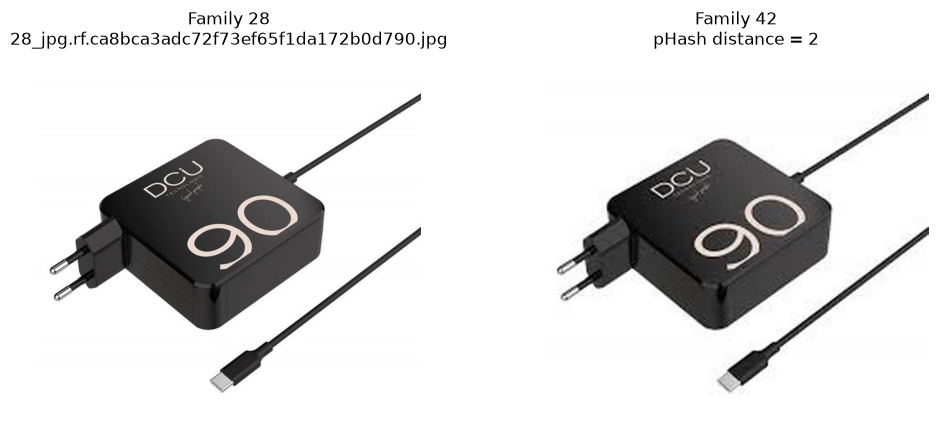

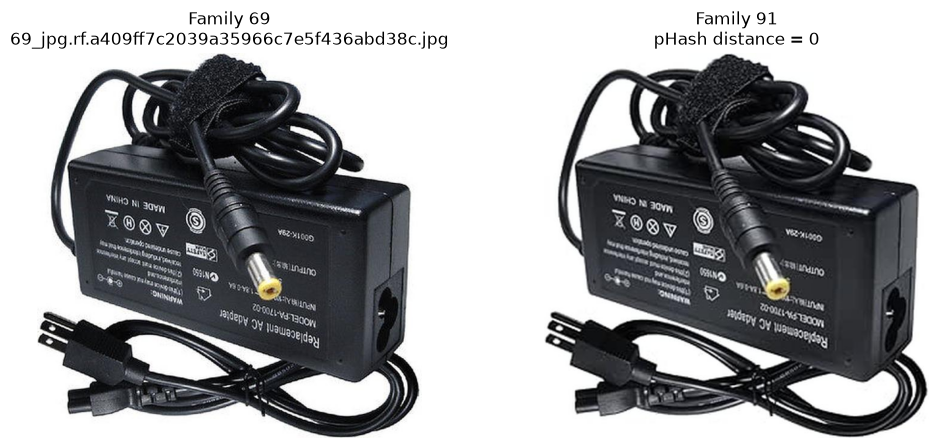

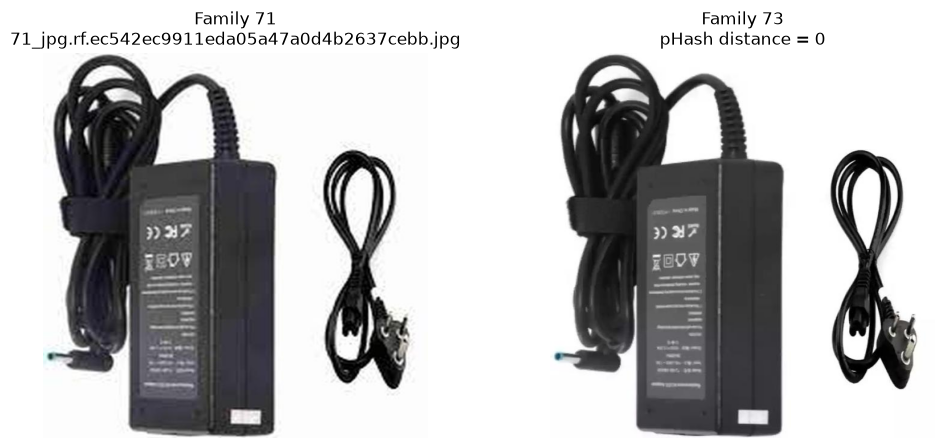

In [20]:
import matplotlib.pyplot as plt
from PIL import Image

for pair in cross_family_near_duplicates:

    row1 = representative_df[
        representative_df["source_family"] == pair["family1"]
    ].iloc[0]

    row2 = representative_df[
        representative_df["source_family"] == pair["family2"]
    ].iloc[0]

    path1 = (
        dataset_path
        / row1["original_split"]
        / "images"
        / row1["file_name"]
    )

    path2 = (
        dataset_path
        / row2["original_split"]
        / "images"
        / row2["file_name"]
    )

    img1 = Image.open(windows_long_path(path1))
    img2 = Image.open(windows_long_path(path2))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(img1)
    axes[0].set_title(
        f"Family {pair['family1']}\n{pair['file1']}"
    )
    axes[0].axis("off")

    axes[1].imshow(img2)
    axes[1].set_title(
        f"Family {pair['family2']}\n"
        f"pHash distance = {pair['distance']}"
    )
    axes[1].axis("off")

    plt.show()

In [21]:
cross_family_duplicate_map = {
    "28": "XDUP01",
    "42": "XDUP01",

    "69": "XDUP02",
    "91": "XDUP02",

    "71": "XDUP03",
    "73": "XDUP03"
}

print(cross_family_duplicate_map)

{'28': 'XDUP01', '42': 'XDUP01', '69': 'XDUP02', '91': 'XDUP02', '71': 'XDUP03', '73': 'XDUP03'}


In [22]:
cross_split_family_set = set(cross_split_families.index.astype(str))

print("Cross-split families:", len(cross_split_family_set))

Cross-split families: 77


In [23]:
representative_lookup = {
    str(row["source_family"]): row["file_name"]
    for _, row in representative_df.iterrows()
}

In [24]:
manifest_df = family_df.copy()

# Make family IDs consistently strings
manifest_df["source_family"] = (
    manifest_df["source_family"].astype(str)
)

# Add charger EDA information
manifest_df = manifest_df.merge(
    charger_df[
        [
            "file_name",
            "original_split",
            "object_count",
            "largest_bbox_ratio"
        ]
    ],
    on=["file_name", "original_split"],
    how="left"
)

# Dataset metadata
manifest_df["source_dataset"] = "sacmaytinh Roboflow v1"
manifest_df["original_label"] = "computer_charger"
manifest_df["esafe_label"] = "charger_adapter"

# Family appears across Roboflow train/valid/test
manifest_df["is_cross_split_family"] = (
    manifest_df["source_family"]
    .isin(cross_split_family_set)
)

# Preferred representative inside each augmentation family
manifest_df["is_primary_candidate"] = manifest_df.apply(
    lambda row:
        row["file_name"]
        == representative_lookup[row["source_family"]],
    axis=1
)

# Cross-family duplicate groups
manifest_df["duplicate_group"] = (
    manifest_df["source_family"]
    .map(cross_family_duplicate_map)
    .fillna("")
)

# One image had no YOLO annotation
manifest_df["missing_source_annotation"] = (
    manifest_df["object_count"] == 0
)

# Everything remains REVIEW until final preprocessing
manifest_df["selection_status"] = "REVIEW"

manifest_df = manifest_df[
    [
        "file_name",
        "source_dataset",
        "original_split",
        "original_label",
        "esafe_label",
        "augmentation_type",
        "source_family",
        "object_count",
        "largest_bbox_ratio",
        "is_cross_split_family",
        "is_primary_candidate",
        "duplicate_group",
        "missing_source_annotation",
        "selection_status"
    ]
]

print(manifest_df.shape)
manifest_df.head()

(450, 14)


,file_name,source_dataset,original_split,original_label,esafe_label,augmentation_type,source_family,object_count,largest_bbox_ratio,is_cross_split_family,is_primary_candidate,duplicate_group,missing_source_annotation,selection_status
0,100_flipped_jpg.rf.3d296e8ae7e0dae14f55b889c05...,sacmaytinh Roboflow v1,train,computer_charger,charger_adapter,flipped,100,1,0.279899,True,False,,False,REVIEW
1,100_rotate270_jpg.rf.9158bd38076810944b661ecbc...,sacmaytinh Roboflow v1,train,computer_charger,charger_adapter,rotate270,100,1,0.278740,True,False,,False,REVIEW
2,100_rotate90_jpg.rf.1ccdb5bd4ac3facc983bc90ac1...,sacmaytinh Roboflow v1,train,computer_charger,charger_adapter,rotate90,100,1,0.335380,True,False,,False,REVIEW
3,10_flipped_jpg.rf.f4264c5a24aa2570c0cb06cfb506...,sacmaytinh Roboflow v1,train,computer_charger,charger_adapter,flipped,10,1,0.342810,False,True,,False,REVIEW
4,10_rotate180_jpg.rf.71efee5518456d616ea07f6c41...,sacmaytinh Roboflow v1,train,computer_charger,charger_adapter,rotate180,10,1,0.327312,False,False,,False,REVIEW


In [25]:
print("Total rows:", len(manifest_df))

print(
    "Unique source families:",
    manifest_df["source_family"].nunique()
)

print(
    "Primary candidates:",
    manifest_df["is_primary_candidate"].sum()
)

print(
    "Cross-split families:",
    manifest_df[
        manifest_df["is_cross_split_family"]
    ]["source_family"].nunique()
)

print(
    "Files belonging to cross-family duplicate groups:",
    (manifest_df["duplicate_group"] != "").sum()
)

print(
    "Duplicate source families:",
    manifest_df[
        manifest_df["duplicate_group"] != ""
    ]["source_family"].nunique()
)

print(
    "Missing source annotations:",
    manifest_df["missing_source_annotation"].sum()
)

Total rows: 450
Unique source families: 98
Primary candidates: 98
Cross-split families: 77
Files belonging to cross-family duplicate groups: 27
Duplicate source families: 6
Missing source annotations: 1


In [26]:
output_path = "../../data/metadata/charger_source1_manifest.csv"

manifest_df.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

Saved: ../../data/metadata/charger_source1_manifest.csv


In [27]:
check_df = pd.read_csv(output_path)

print(check_df.shape)
check_df.head()

(450, 14)


,file_name,source_dataset,original_split,original_label,esafe_label,augmentation_type,source_family,object_count,largest_bbox_ratio,is_cross_split_family,is_primary_candidate,duplicate_group,missing_source_annotation,selection_status
0,100_flipped_jpg.rf.3d296e8ae7e0dae14f55b889c05...,sacmaytinh Roboflow v1,train,computer_charger,charger_adapter,flipped,100,1,0.279899,True,False,NaN,False,REVIEW
1,100_rotate270_jpg.rf.9158bd38076810944b661ecbc...,sacmaytinh Roboflow v1,train,computer_charger,charger_adapter,rotate270,100,1,0.278740,True,False,NaN,False,REVIEW
2,100_rotate90_jpg.rf.1ccdb5bd4ac3facc983bc90ac1...,sacmaytinh Roboflow v1,train,computer_charger,charger_adapter,rotate90,100,1,0.335380,True,False,NaN,False,REVIEW
3,10_flipped_jpg.rf.f4264c5a24aa2570c0cb06cfb506...,sacmaytinh Roboflow v1,train,computer_charger,charger_adapter,flipped,10,1,0.342810,False,True,NaN,False,REVIEW
4,10_rotate180_jpg.rf.71efee5518456d616ea07f6c41...,sacmaytinh Roboflow v1,train,computer_charger,charger_adapter,rotate180,10,1,0.327312,False,False,NaN,False,REVIEW


# EDA Conclusions — sacmaytinh Roboflow v1 → `charger_adapter`

## Dataset Structure

- Source: Roboflow Universe — `sacmaytinh`.
- Dataset version: 1.
- Licence: CC BY 4.0.
- Original class: `computer_charger`.
- The original class maps to the E-Safe Dataset A class `charger_adapter`.
- The downloaded dataset contains 450 images:
  - Train: 315
  - Validation: 90
  - Test: 45
- Every image has a corresponding TXT annotation file.
- All annotation objects use class ID 0 (`computer_charger`).

## Image and Annotation Quality

- All 450 images are 640 × 640 pixels.
- No corrupt images were detected.
- 441 images contain one annotated charger.
- 8 images contain two annotated charger objects.
- 1 image contains zero annotated objects.
- The zero-annotation image was manually inspected and clearly contains a charger/adapter, indicating a missing source annotation rather than an irrelevant image.

## Visual Observations

Manual inspection showed that:

- The charger/adapter body is clearly identifiable in most images.
- The source mainly represents laptop/computer power adapters and larger power-supply bricks.
- A small number of high-power USB/multi-port charging adapters are also present.
- Phone-style charging bricks do not appear to be strongly represented.
- Attached charging cables are common, but the adapter body is generally still identifiable as the intended object.
- Some images also contain laptops or other contextual objects.
- In a few images the laptop occupies a large portion of the frame, although the charger remains visible.
- Most images appear to be clean product-style photographs.
- White backgrounds dominate strongly.
- Natural, cluttered or e-waste-style environments are poorly represented.

Therefore, this source provides useful charger/adapter appearance data but has a strong product-image and laptop-adapter bias.

## Object Prominence

Largest charger bounding-box area ratio:

- Mean: 0.3641 (~36.41%)
- Median: 0.3297 (~32.97%)
- 25th percentile: 0.2292 (~22.92%)
- 75th percentile: 0.4871 (~48.71%)
- Minimum: 0.0262 (~2.62%)
- Maximum: 0.9254 (~92.54%)

The charger is therefore reasonably prominent in most images, although a small number of images contain relatively small charger regions and should be reviewed during final preprocessing.

## Augmentation Analysis

The downloaded dataset contains heavy pre-generated augmentation.

Among the 450 files:

- 89 are explicitly identified as original images.
- 91 are flipped variants.
- 89 are 90-degree rotated variants.
- 90 are 180-degree rotated variants.
- 91 are 270-degree rotated variants.

After grouping filenames by their underlying source image, only 98 source-image families remain.

Family-size distribution:

- 7 families contain 3 variants.
- 26 families contain 4 variants.
- 65 families contain 5 variants.

Therefore, the 450 files must not be treated as 450 independent real-world charger photographs.

## Source Split Leakage

77 of the 98 source-image families appear across more than one of the provided train/validation/test splits.

Examples include an original image in one split and its rotated or flipped version in another split.

Therefore, the Roboflow train/validation/test split contains substantial augmentation-family leakage and must not be used as the final E-Safe evaluation split.

All variants belonging to the same source family must remain together during future E-Safe splitting.

## Cross-Family Duplicate Analysis

One representative image was selected from each of the 98 source families.

Perceptual-hash comparison between these representatives identified three suspicious pairs:

- Family 28 ↔ Family 42
- Family 69 ↔ Family 91
- Family 71 ↔ Family 73

All three pairs were manually inspected and confirmed to represent the same or effectively identical images.

These are recorded as cross-family duplicate groups `XDUP01`, `XDUP02`, and `XDUP03`.

After accounting for these pairs, the source contains approximately 95 genuinely distinct charger scenes.

## Overall Suitability

This dataset is suitable as Source 1 for the E-Safe `charger_adapter` class, but it should not be used alone.

Its main strengths are:

- clear charger/adapter visibility
- strong laptop/power-adapter representation
- consistent image quality
- reliable class relevance

Its main limitations are:

- only about 95 genuinely distinct scenes despite 450 files
- heavy rotation/flip augmentation
- severe leakage in the source train/validation/test split
- strong white-background/product-photo bias
- limited apparent phone-wall-charger representation
- limited real-world/e-waste environment diversity

A complementary Source 2 should therefore focus on phone/wall chargers, general AC/DC adapters and more natural or used-device imagery.

# Future Work / Preprocessing Decisions — Charger Source 1

- Keep the downloaded raw dataset unchanged.
- Map `computer_charger` to the E-Safe Dataset A label `charger_adapter`.
- Preserve the original Roboflow train/validation/test split only as metadata.
- Do not use the provided source split for final model evaluation because augmentation families leak across splits.
- Use `source_family` to group all transformed versions originating from the same underlying image.
- All files from one source family must remain in the same final E-Safe split.
- Prefer the original image as the representative of a source family whenever it exists.
- For the 9 source families without an explicitly named original file, retain one suitable transformed variant as the family representative.
- Do not count rotations and flips as independent real-world samples.
- If transformed variants are retained at all, they should only be used as training augmentation and never as independent validation/test examples.
- During final cleaning, account for the three confirmed cross-family duplicate groups and retain only one independent source scene from each duplicate group.
- Keep the zero-annotation image as a review candidate because manual inspection confirms that it contains a charger/adapter despite the missing source bounding box.
- Review images where the charger occupies a very small portion of the image or another object such as a laptop dominates the scene.
- Do not apply a fixed bounding-box threshold automatically; manually review borderline images.
- This source should be supplemented with another independent dataset containing more phone charging bricks, wall adapters, general AC/DC chargers and natural/real-world backgrounds.
- Final Dataset A merging, balancing, duplicate removal and train/validation/test splitting will be performed later during preprocessing.
- Dataset A remains an item-recognition dataset. Charger damage or safety hazards belong to Dataset B.